In [27]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x): return 1 / (1 + np.exp(-x))
def sigmoid_deriv(x): return x * (1 - x)

In [28]:
def run_mlp_lab(name, X, y):
    print(f"\n--- Training {name} Gate ---")
    wh = np.random.uniform(size=(2, 2))
    bh = np.random.uniform(size=(1, 2))
    wo = np.random.uniform(size=(2, 1))
    bo = np.random.uniform(size=(1, 1))
    
    lr, epochs = 0.5, 10000
    loss_history = []

    for i in range(epochs):
        # Forward
        h_act = sigmoid(np.dot(X, wh) + bh)
        o_act = sigmoid(np.dot(h_act, wo) + bo)
        
        # Loss
        loss = np.mean(np.square(y - o_act))
        loss_history.append(loss)
        
        # Backprop
        d_out = (o_act - y) * sigmoid_deriv(o_act)
        d_hid = d_out.dot(wo.T) * sigmoid_deriv(h_act)
        
        # Update
        wo -= h_act.T.dot(d_out) * lr
        bo -= np.sum(d_out, axis=0) * lr
        wh -= X.T.dot(d_hid) * lr
        bh -= np.sum(d_hid, axis=0) * lr

    # Print Results
    for j in range(len(X)):
        pred = 1 if o_act[j] > 0.5 else 0
        print(f"Input: {X[j]}, Target: {y[j]}, Pred: {pred}")

    # Plotting
    plt.figure(figsize=(10, 4))
    
    # Loss Plot
    plt.subplot(1, 2, 1)
    plt.plot(loss_history)
    plt.title(f"{name} Loss")
    plt.xlabel("Epochs")
    
    # Boundary Plot
    plt.subplot(1, 2, 2)
    x_range = np.linspace(-0.5, 1.5, 50)
    xx, yy = np.meshgrid(x_range, x_range)
    grid = np.c_[xx.ravel(), yy.ravel()]
    
    h_grid = sigmoid(np.dot(grid, wh) + bh)
    o_grid = sigmoid(np.dot(h_grid, wo) + bo).reshape(xx.shape)
    
    plt.contourf(xx, yy, o_grid, alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y.flatten(), edgecolors='k')
    plt.title(f"{name} Boundary")
    plt.show()


--- Training AND Gate ---
Input: [0 0], Target: [0], Pred: 0
Input: [0 1], Target: [0], Pred: 0
Input: [1 0], Target: [0], Pred: 0
Input: [1 1], Target: [1], Pred: 1


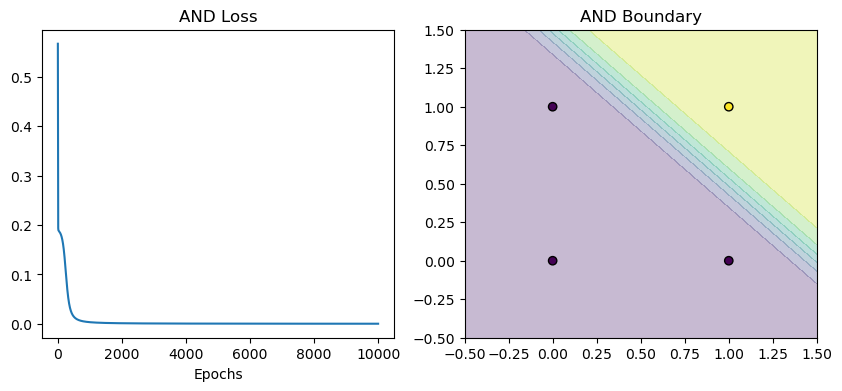


--- Training XOR Gate ---
Input: [0 0], Target: [0], Pred: 0
Input: [0 1], Target: [1], Pred: 1
Input: [1 0], Target: [1], Pred: 1
Input: [1 1], Target: [0], Pred: 0


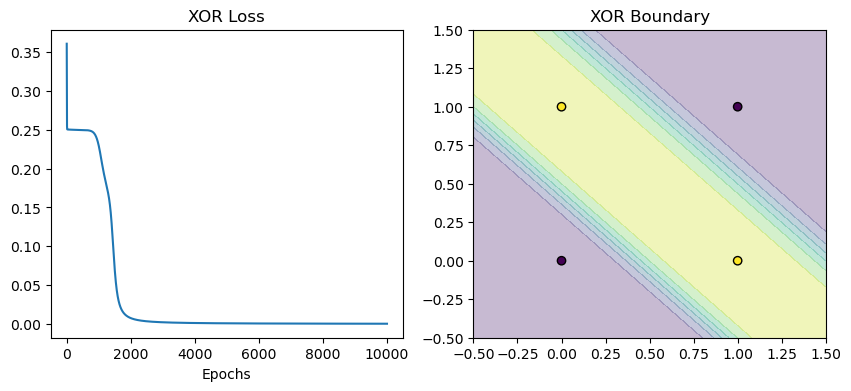

In [29]:
X = np.array([[0,0], [0,1], [1,0], [1,1]])
run_mlp_lab("AND", X, np.array([[0], [0], [0], [1]]))
run_mlp_lab("XOR", X, np.array([[0], [1], [1], [0]]))